In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/results/outlines_data_results.csv')

df['ShortFile'] = df['File'].str.replace('.csv', '', regex=False)

metric_cols = ['Accuracy','Recall (macro)']

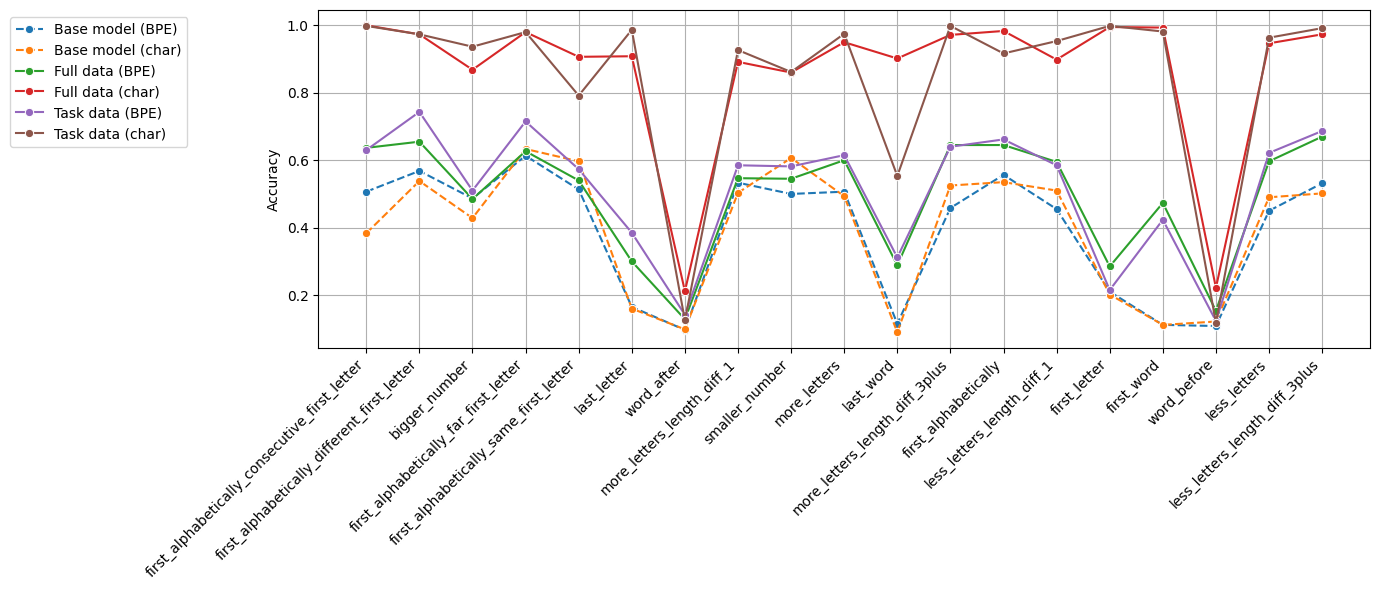

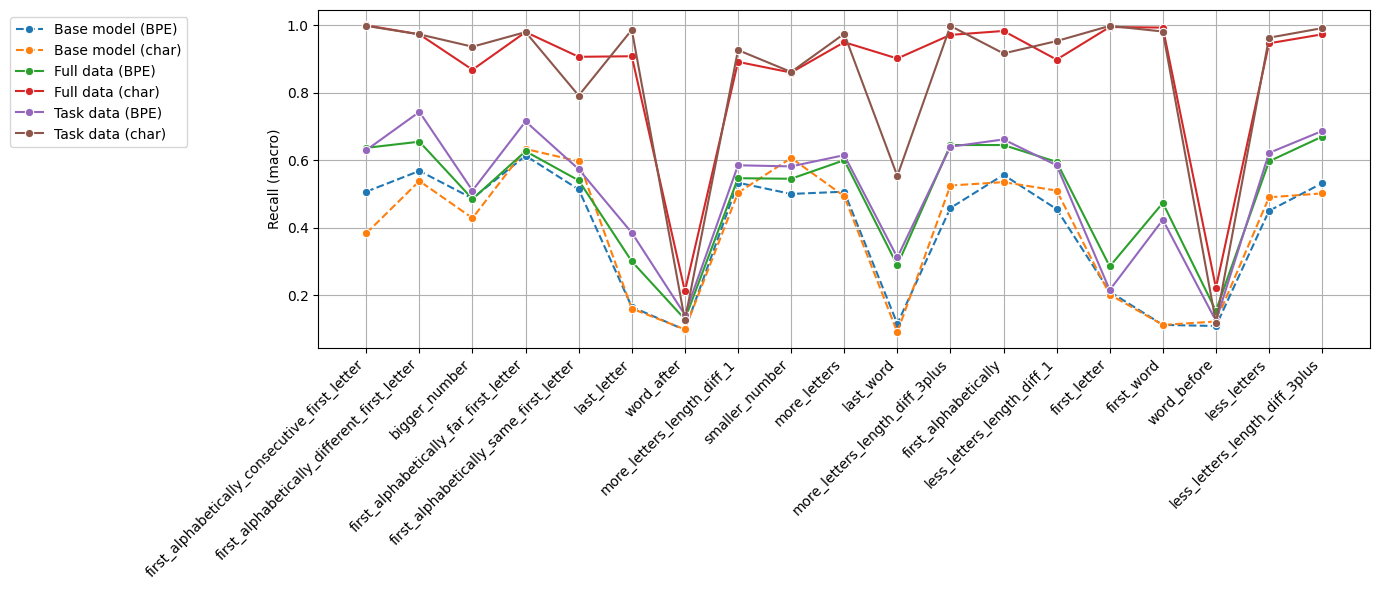

In [3]:
melted = df.melt(id_vars=['ShortFile', 'Subfolder'], 
                 value_vars=metric_cols,
                 var_name='Metrik', 
                 value_name='Wert')

metrics = ['Accuracy','Recall (macro)']

melted_de = melted[melted['Subfolder'].str.contains('_de', na=False)]

for metric in metrics:
    subset = melted_de[melted_de['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("de", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.3, 1), loc="upper left")
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.show()


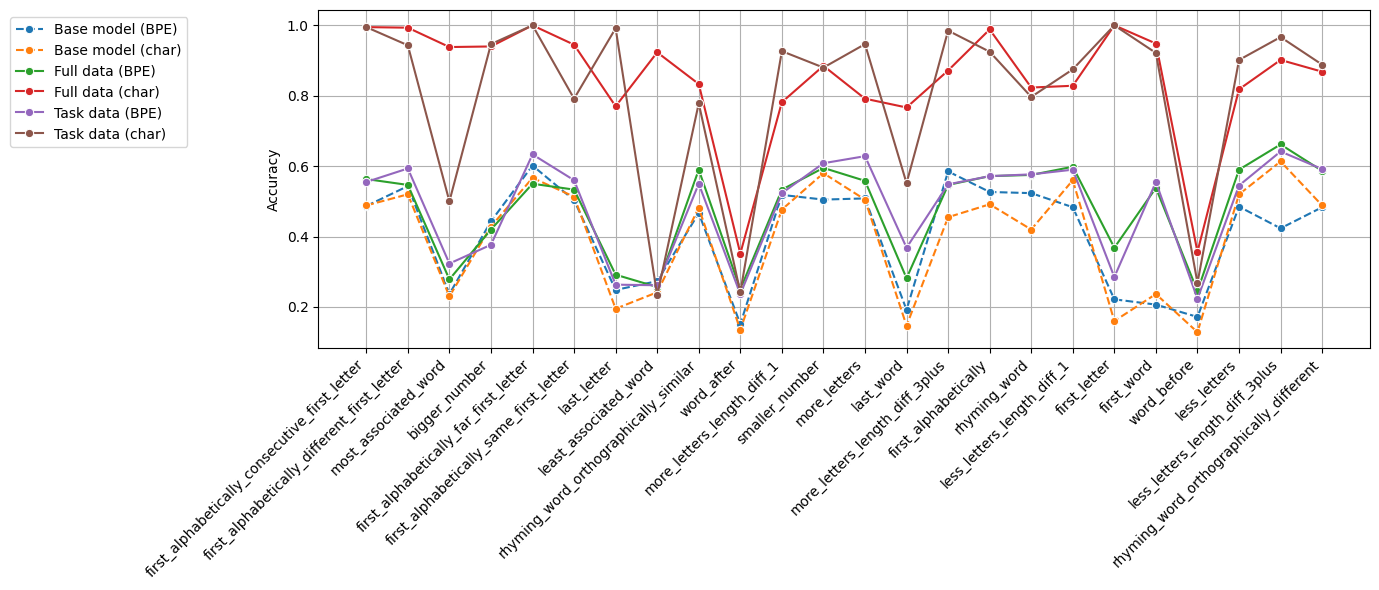

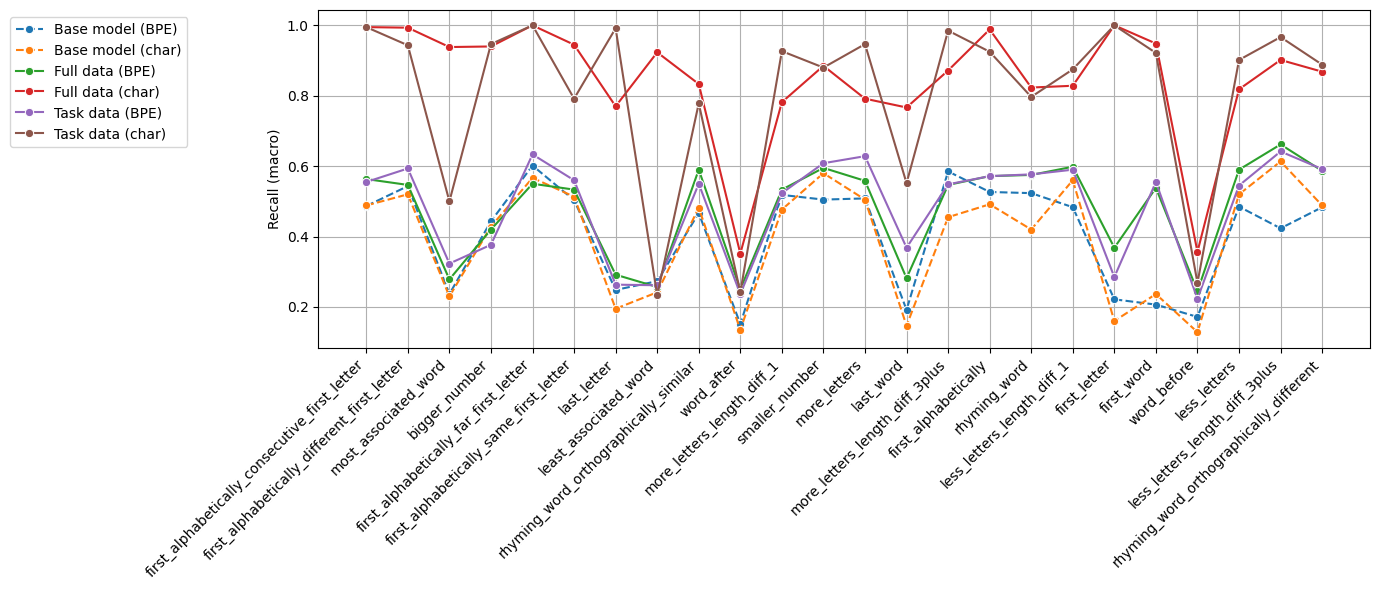

In [4]:
melted_en = melted[melted['Subfolder'].str.contains('_en', na=False)]

for metric in metrics:
    subset = melted_en[melted_en['Metrik'] == metric]
    
    plt.figure(figsize=(14, 6))
    
    # Subfolder durchgehen und jeweils plotten
    for subfolder, data in subset.groupby("Subfolder"):
        if not subfolder.startswith("baseline_"):
            linestyle = "--" if subfolder.startswith("base_") else "-"
            parts = [x for x in subfolder.split("_") if x not in ("en", "train")]

            if parts:
                last = parts[-1]
                if last.lower() == "bpe":
                    last = last.upper()
                else:
                    last = last.lower()
                subfolder = " ".join(parts[:-1] + [f"({last})"])
                subfolder = subfolder[0].upper() + subfolder[1:]  # erster Buchstabe groß
            else:
                subfolder = ""
            sns.lineplot(
                data=data,
                x="ShortFile",
                y="Wert",
                label=subfolder,
                marker="o",
                linestyle=linestyle
            )
    
    plt.xlabel("")
    plt.ylabel(metric) 
    # plt.title(f"{metric} über Modellvarianten hinweg zu jedem Task")
    plt.legend(bbox_to_anchor=(-0.3, 1), loc="upper left")
    
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)  # Gitter hinzufügen
    plt.tight_layout()
    plt.show()
